# Akamai CCM demo

[Akamai Cloud Certificate Manager](https://techdocs.akamai.com/ccm/docs/welcome) (CCM) is the *new* CPS, which simplifies the management of third-party certificates.

It:

- Minimizes the information needed to create third-party certificates.
- Separates certificate configuration from network configuration into two independent workflows, simplifying certificate provisioning.
- Together with Property Manager, binds certificates to hostnames and configurations independently, supporting mutual authentication and improving resource efficiency.

This API-based demo will create a CSR, generate a self-signed cert from it valid for 180 days, and upload the certificate to CCM.
In your delivery configuration, you can then add or update a hostname using CCM as the certificate option.

*The last cell will **delete** the certificate again to clean up the demo.*

## Setup EdgeGrid session

Let's first setup an EdgeGrid session using information from the `~/.edgerc` file. The correct *section* can be set via `export AKAMAI_EDGEGRID_SECTION=section`; otherwise, `default` is going to be used.
Make sure your API user has the [CCM permissions](https://techdocs.akamai.com/ccm/reference/get-started). 

This notebook supports the `AccountSwitchKey` option which can be set via `export AKAMAI_ACCOUNT_SWITCH_KEY="1-2345:A-BCDE"`

*Make sure to select a `section` or `AccountSwitchKey` that has CCM enabled on that contract!*

In [ ]:
import json
import os

import requests
from akamai.edgegrid import EdgeGridAuth, EdgeRc

edgerc_path = os.path.expanduser("~/.edgerc")

if not os.path.exists(edgerc_path):
    raise FileNotFoundError(f"Could not find .edgerc at {edgerc_path}")

section = os.getenv("AKAMAI_EDGEGRID_SECTION", "default")
account_switch_key = os.getenv("AKAMAI_ACCOUNT_SWITCH_KEY")

edgerc = EdgeRc(edgerc_path)
host = edgerc.get(section, "host")

session = requests.Session()
session.auth = EdgeGridAuth.from_edgerc(edgerc, section)
session.headers.update({
    "Accept": "application/json",
    "Content-Type": "application/json",
})

base_url = f"https://{host}"
print(f"EdgeGrid session configured for host: {host}")

if account_switch_key:
    print(f"Using AccountSwitchKey: {account_switch_key}")

## Create Certificate Signing Request

You need a `contractId` and `groupId` so the certificate is placed in the correct contract and group in your Akamai account.
Set them before running this cell:

```
export AKAMAI_CONTRACT_ID="ABC"
export AKAMAI_GROUP_ID="123"
```

When the EdgeGrid session is up, this cell creates a Certificate Signing Request (CSR) using an automatically generated *coolname* hostname under **great-demo.com** (overridable via `AKAMAI_DEMO_BASE_DOMAIN`).

*Make sure to select a contract that has CCM enabled!*

### Payload

The full list of payload options is documented here: [POST /ccm/v1/certificates](https://techdocs.akamai.com/ccm/reference/post-certificates).
This example requests an `ECDSA` certificate on the **Enhanced TLS** (`ENHANCED_TLS`) network.

In [ ]:
from coolname import generate_slug

# Required query parameters for POST /ccm/v1/certificates
contract_id = os.getenv("AKAMAI_CONTRACT_ID")
group_id = os.getenv("AKAMAI_GROUP_ID")

if not contract_id or not group_id:
    raise ValueError(
        "Set AKAMAI_CONTRACT_ID and AKAMAI_GROUP_ID before creating a certificate."
    )

params = {
    "contractId": contract_id,
    "groupId": group_id,
}

# Account switch key is optional and already read in the setup cell.
if account_switch_key:
    params["accountSwitchKey"] = account_switch_key

# Demo-only Docker-like random name generator using coolname.
random_name = generate_slug(2)
demo_base_domain = os.getenv("AKAMAI_DEMO_BASE_DOMAIN", "great-demo.com")
common_name = f"{random_name}.{demo_base_domain}"
san_name = f"www.{common_name}"
certificate_name = f"CCM API Demo {random_name}"

payload = {
    "keySize": "P-256",
    "keyType": "ECDSA",
    "secureNetwork": "ENHANCED_TLS",
    "certificateName": certificate_name,
    "subject": {
        "commonName": common_name,
        "country": "NL",
        "locality": "Amsterdam",
        "organization": "Akamai Great Demo",
        "state": "NH",
    },
    "sans": [san_name],
}

print("Using demo names:")
print("  certificateName:", certificate_name)
print("  commonName:", common_name)
print("  san:", san_name)

url = f"{base_url}/ccm/v1/certificates"
response = session.post(url, params=params, json=payload, timeout=30)

print("Status:", response.status_code)
try:
    response_json = response.json()
except ValueError:
    response_json = {"raw": response.text}

if not response.ok:
    print("Request failed:")
    print(json.dumps(response_json, indent=2))
    response.raise_for_status()

print("Certificate request created:")
print(json.dumps(response_json, indent=2))

## Get csrPEM

When successful, you should see your CSR in CCM on Akamai Control Center:  
<div align="left">
    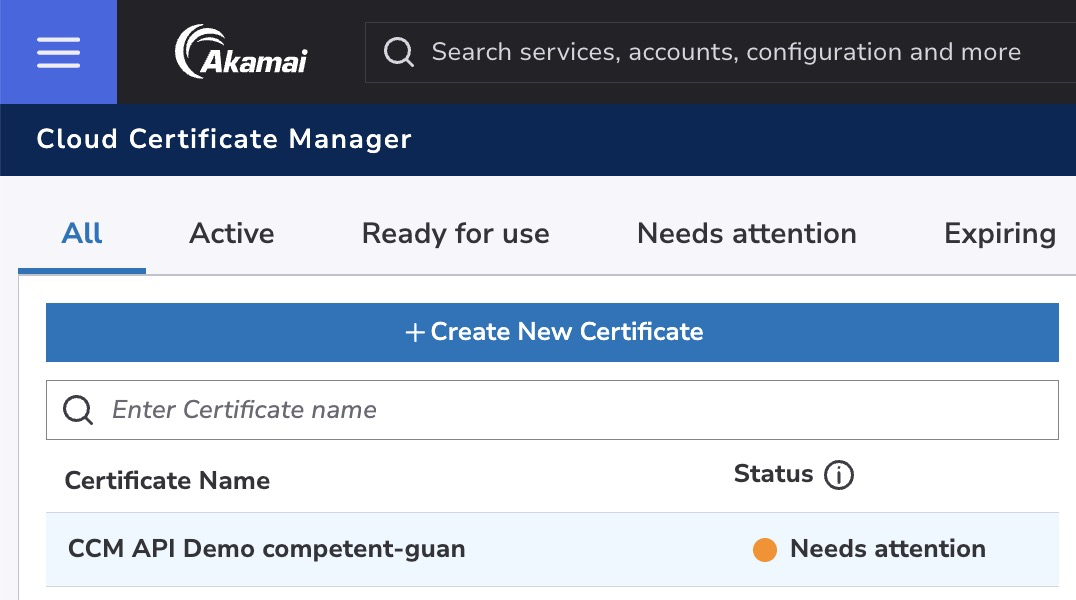
</div>  

Now, get the PEM from this CSR; we're going to use that to request the certificate.

In [ ]:
# Extract csrPem from the previous successful response.
if "response_json" not in globals():
    raise RuntimeError("Run the previous request cell first to populate response_json.")

if not isinstance(response_json, dict):
    raise TypeError("response_json is not a JSON object; cannot extract csrPem.")

csr_pem = response_json.get("csrPem")

if not csr_pem:
    print("Could not find csrPem. Top-level keys:", list(response_json.keys()))
    raise KeyError("csrPem was not found in the API response.")

print("csrPem extracted and ready for certificate request.")
print(csr_pem)

## Request certificate

Now that we have the CSR, create a self-signed cert from it. 
For this demo, no need to request a *real* certificate in production, you would use your favorite CA to request a certificate.

In [ ]:
from datetime import UTC, datetime, timedelta

from cryptography import x509
from cryptography.hazmat.primitives import hashes, serialization
from cryptography.hazmat.primitives.asymmetric import ec
from cryptography.x509.oid import NameOID

if "csr_pem" not in globals() or not csr_pem:
    raise RuntimeError("Run the Get csrPEM cell first so csr_pem is available.")

csr = x509.load_pem_x509_csr(csr_pem.encode())
if not csr.is_signature_valid:
    raise ValueError("CSR signature is not valid.")

cn_attrs = csr.subject.get_attributes_for_oid(NameOID.COMMON_NAME)
common_name = cn_attrs[0].value if cn_attrs else "demo.local"

try:
    san_ext = csr.extensions.get_extension_for_class(x509.SubjectAlternativeName)
    san_value = san_ext.value
except x509.ExtensionNotFound:
    san_value = x509.SubjectAlternativeName([x509.DNSName(common_name)])

ca_key = ec.generate_private_key(ec.SECP256R1())
ca_subject = x509.Name([
    x509.NameAttribute(NameOID.COUNTRY_NAME, "NL"),
    x509.NameAttribute(NameOID.ORGANIZATION_NAME, "Demo Local CA"),
    x509.NameAttribute(NameOID.COMMON_NAME, "Demo Self-Signed Root"),
])

now = datetime.now(UTC)
ca_cert = (
    x509.CertificateBuilder()
    .subject_name(ca_subject)
    .issuer_name(ca_subject)
    .public_key(ca_key.public_key())
    .serial_number(x509.random_serial_number())
    .not_valid_before(now - timedelta(minutes=5))
    .not_valid_after(now + timedelta(days=365))
    .add_extension(x509.BasicConstraints(ca=True, path_length=None), critical=True)
    .sign(private_key=ca_key, algorithm=hashes.SHA256())
)

demo_cert = (
    x509.CertificateBuilder()
    .subject_name(csr.subject)
    .issuer_name(ca_cert.subject)
    .public_key(csr.public_key())
    .serial_number(x509.random_serial_number())
    .not_valid_before(now - timedelta(minutes=5))
    .not_valid_after(now + timedelta(days=180))
    .add_extension(x509.BasicConstraints(ca=False, path_length=None), critical=True)
    .add_extension(san_value, critical=False)
    .sign(private_key=ca_key, algorithm=hashes.SHA256())
)

demo_cert_pem = demo_cert.public_bytes(serialization.Encoding.PEM).decode()
demo_ca_pem = ca_cert.public_bytes(serialization.Encoding.PEM).decode()

print("Created local demo certificate from CSR.")
print("Subject CN:", common_name)

## Upload certificate

We used the CSR to create a self-signed certificate. Now upload it back to CCM to complete the certificate request — this is the step that would normally be done by your CA returning the signed certificate.

In [ ]:
if "session" not in globals() or "base_url" not in globals() or "account_switch_key" not in globals():
    raise RuntimeError("Run the EdgeGrid setup cell first.")

if "response_json" not in globals() or not isinstance(response_json, dict):
    raise RuntimeError("Run the certificate request cell first to get response_json.")

if "demo_cert_pem" not in globals() or "demo_ca_pem" not in globals():
    raise RuntimeError("Run the self-signed generation cell first.")

certificate_id = os.getenv("AKAMAI_CERTIFICATE_ID") or str(response_json.get("certificateId", "")).strip()
if not certificate_id:
    raise RuntimeError("No certificateId found. Set AKAMAI_CERTIFICATE_ID or run create request cell.")

params = {}
if account_switch_key:
    params["accountSwitchKey"] = account_switch_key

upload_payload = {
    "signedCertificatePem": demo_cert_pem,
    "trustChainPem": demo_ca_pem,
}

upload_url = f"{base_url}/ccm/v1/certificates/{certificate_id}"
upload_response = session.put(upload_url, params=params, json=upload_payload, timeout=30)

print("Upload status:", upload_response.status_code)
try:
    upload_response_json = upload_response.json()
except ValueError:
    upload_response_json = {"raw": upload_response.text}

if not upload_response.ok:
    response_type = upload_response_json.get("type") if isinstance(upload_response_json, dict) else None
    if upload_response.status_code == 409 and response_type == "/error-types/upload-certificate-validation-warnings":
        print("Upload accepted with warnings (validation warnings).")
        print(json.dumps(upload_response_json, indent=2))
    else:
        print("Upload failed:")
        print(json.dumps(upload_response_json, indent=2))
        upload_response.raise_for_status()

if upload_response.ok:
    print("Certificate uploaded successfully.")
    print(json.dumps(upload_response_json, indent=2))

## Ready to use

Now you should be ready to use the certificate and you should see this:
<div align="left">
    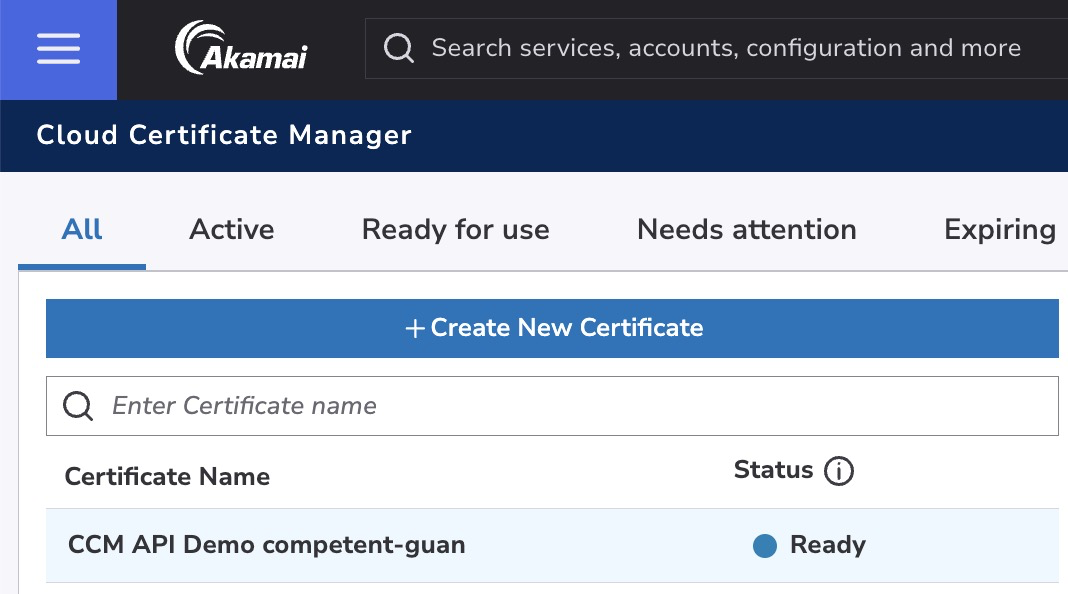
</div>  

## Assign Certificate to hostname
Your newly created CCM certificate can now be assigned in your Delivery Configuration to a hostname  

<div align="left">
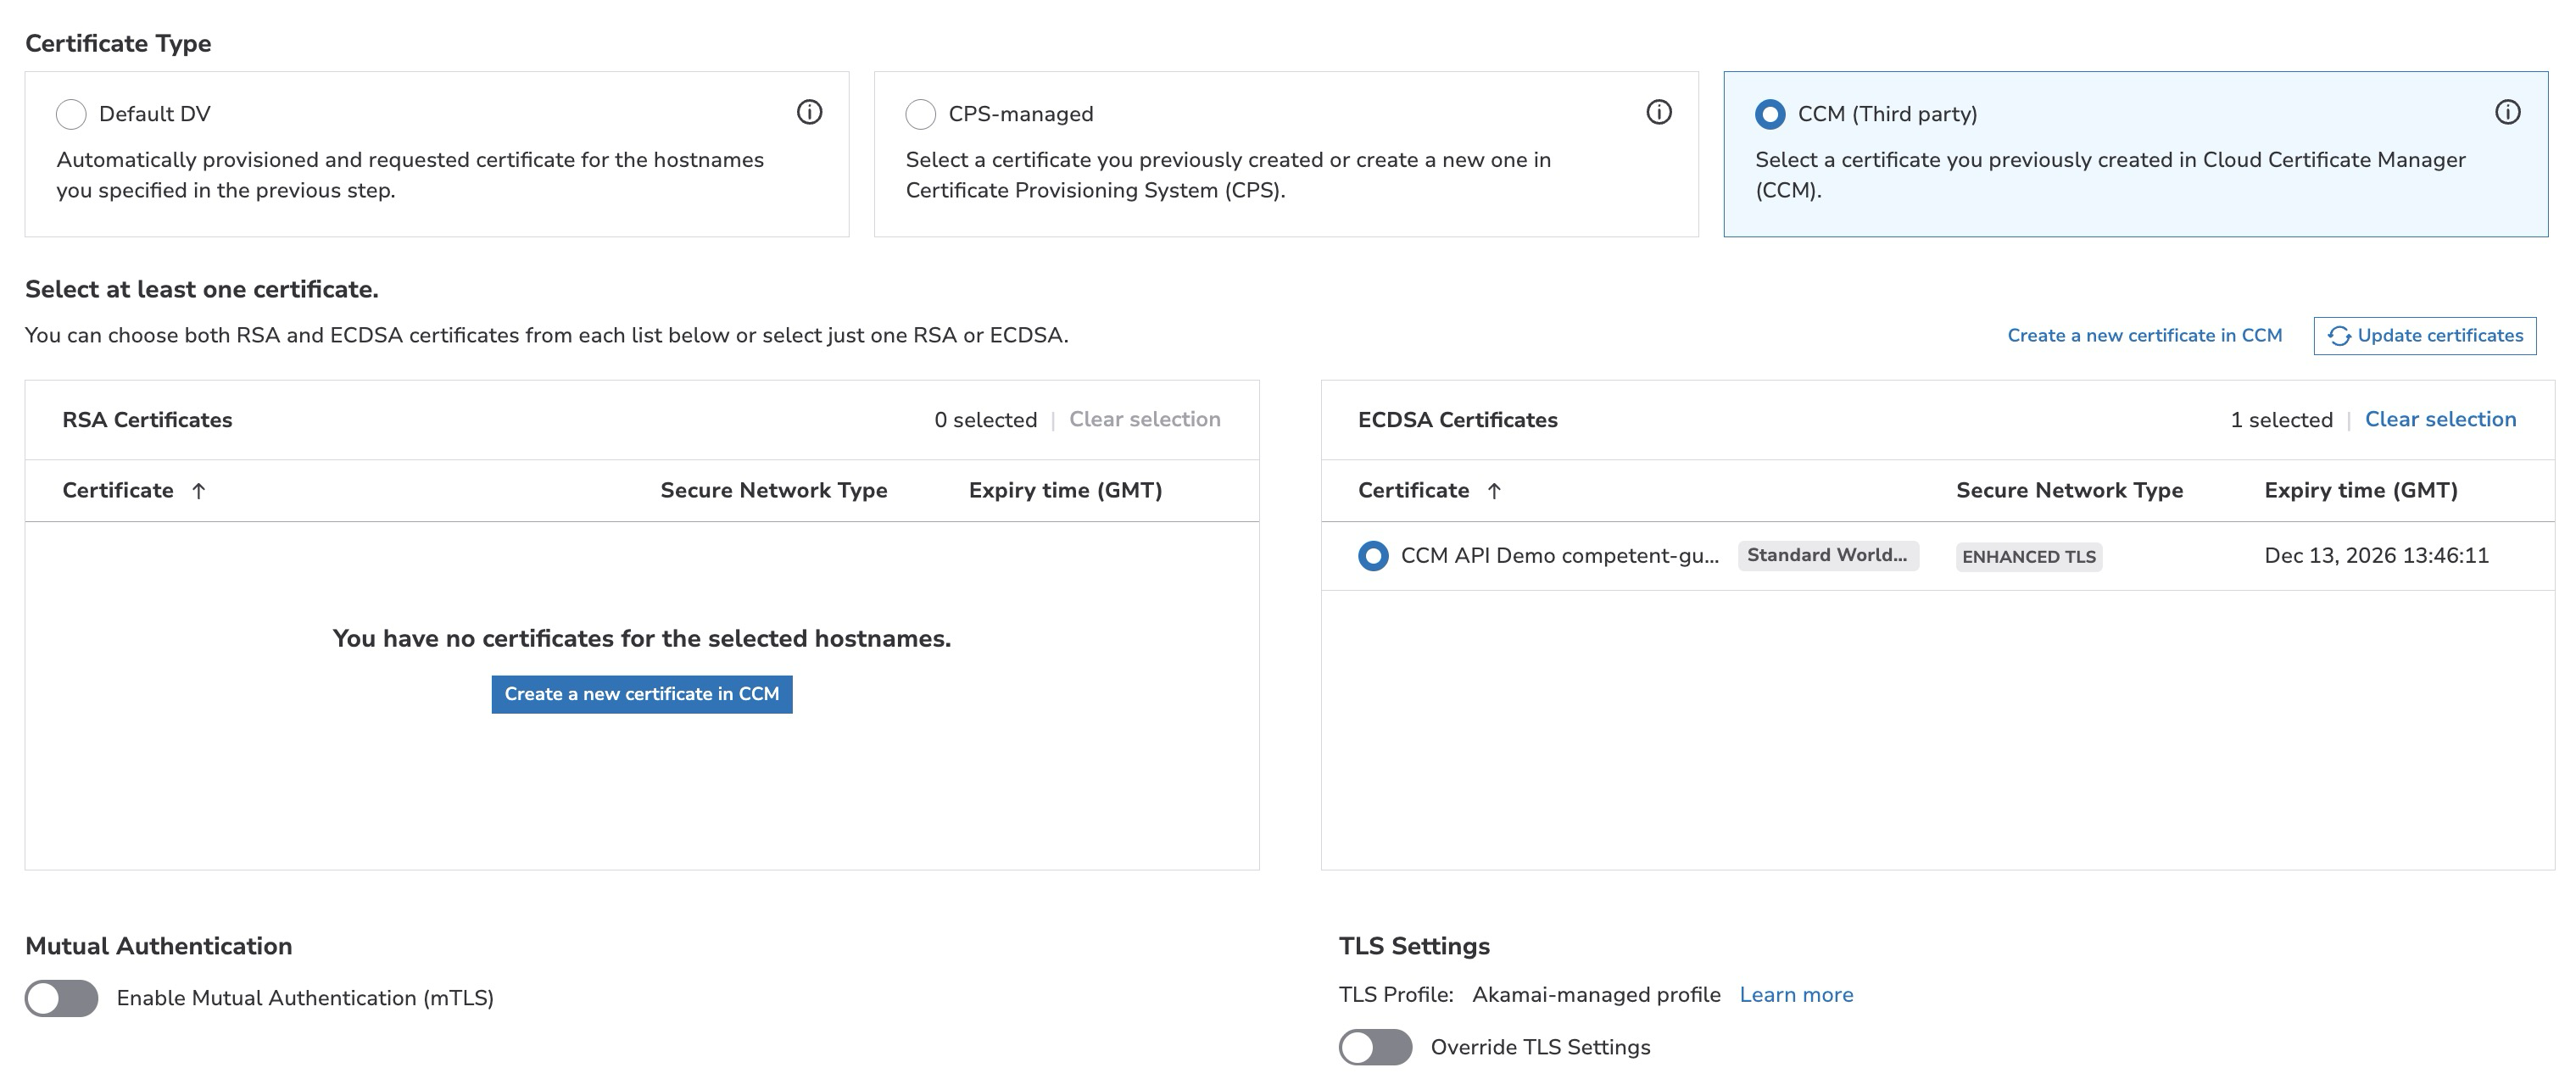
</div>  

Now just push to staging to test and when all fine push to production and off you go.

## Delete certificate

Run this cell to delete the certificate and clean up after the demo.

In [ ]:
if "session" not in globals() or "base_url" not in globals() or "account_switch_key" not in globals():
    raise RuntimeError("Run the EdgeGrid setup cell first.")

if "response_json" not in globals() or not isinstance(response_json, dict):
    raise RuntimeError("Run the certificate request cell first to get response_json.")

certificate_id = os.getenv("AKAMAI_CERTIFICATE_ID") or str(response_json.get("certificateId", "")).strip()
if not certificate_id:
    raise RuntimeError("No certificateId found. Set AKAMAI_CERTIFICATE_ID or run create request cell.")

params = {}
if account_switch_key:
    params["accountSwitchKey"] = account_switch_key

delete_url = f"{base_url}/ccm/v1/certificates/{certificate_id}"
delete_response = session.delete(delete_url, params=params, timeout=30)

print("Delete status:", delete_response.status_code)

if delete_response.status_code == 204:
    print("Certificate deleted successfully.")
else:
    try:
        delete_response_json = delete_response.json()
    except ValueError:
        delete_response_json = {"raw": delete_response.text}

    print(json.dumps(delete_response_json, indent=2))
    delete_response.raise_for_status()